In [1]:
import os
import sys
import numpy as np
import fitsio
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
import src.correlation_tools as ct
import src.subvolume_utils as su
import src.plotting as pg

from dotenv import load_dotenv
load_dotenv()

g_base = os.getenv('galaxy_base')
c_base = os.getenv('cluster_base')
h_base = os.getenv('halo_base')
data_dir = os.getenv('data_dir')
galaxies = f"{g_base}base_c000_ph000/z0p300/model_hod000000/gals.fit"
clusters = f"{c_base}base_c000_ph000/z0p300/model_hod000000/richness_q180_bg.fit"
sub_ = 4

# Cluster visualizations

In [2]:
wp_cluster = []
rp_cluster= []
for i in range (25):
    data = np.load(f'{data_dir}wp_cluster_counts_ph{i:03d}.npz')
    wp_cluster.append(data['wp'])
    rp_cluster.append(data['rp'])
wp_cluster = np.concatenate(wp_cluster)
rp_cluster = np.concatenate(rp_cluster)

17.904777715231194 4242.5594706283155


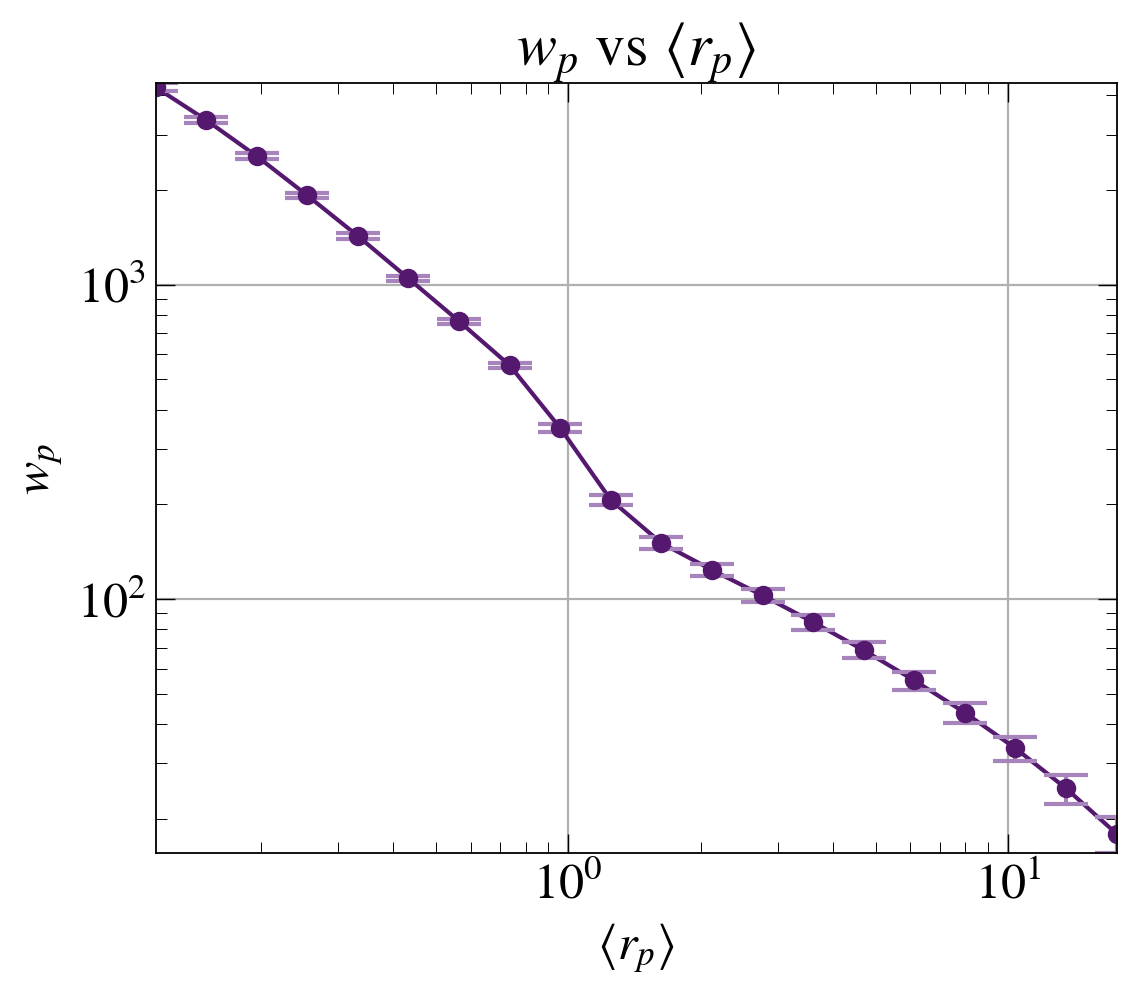

In [3]:
rpavg_mean_c, wp_mean_c, stdev_c = ct.error_data(rp_cluster, wp_cluster)
pg.wp_vs_rpavg(rpavg_mean_c, wp_mean_c, stdev_c)

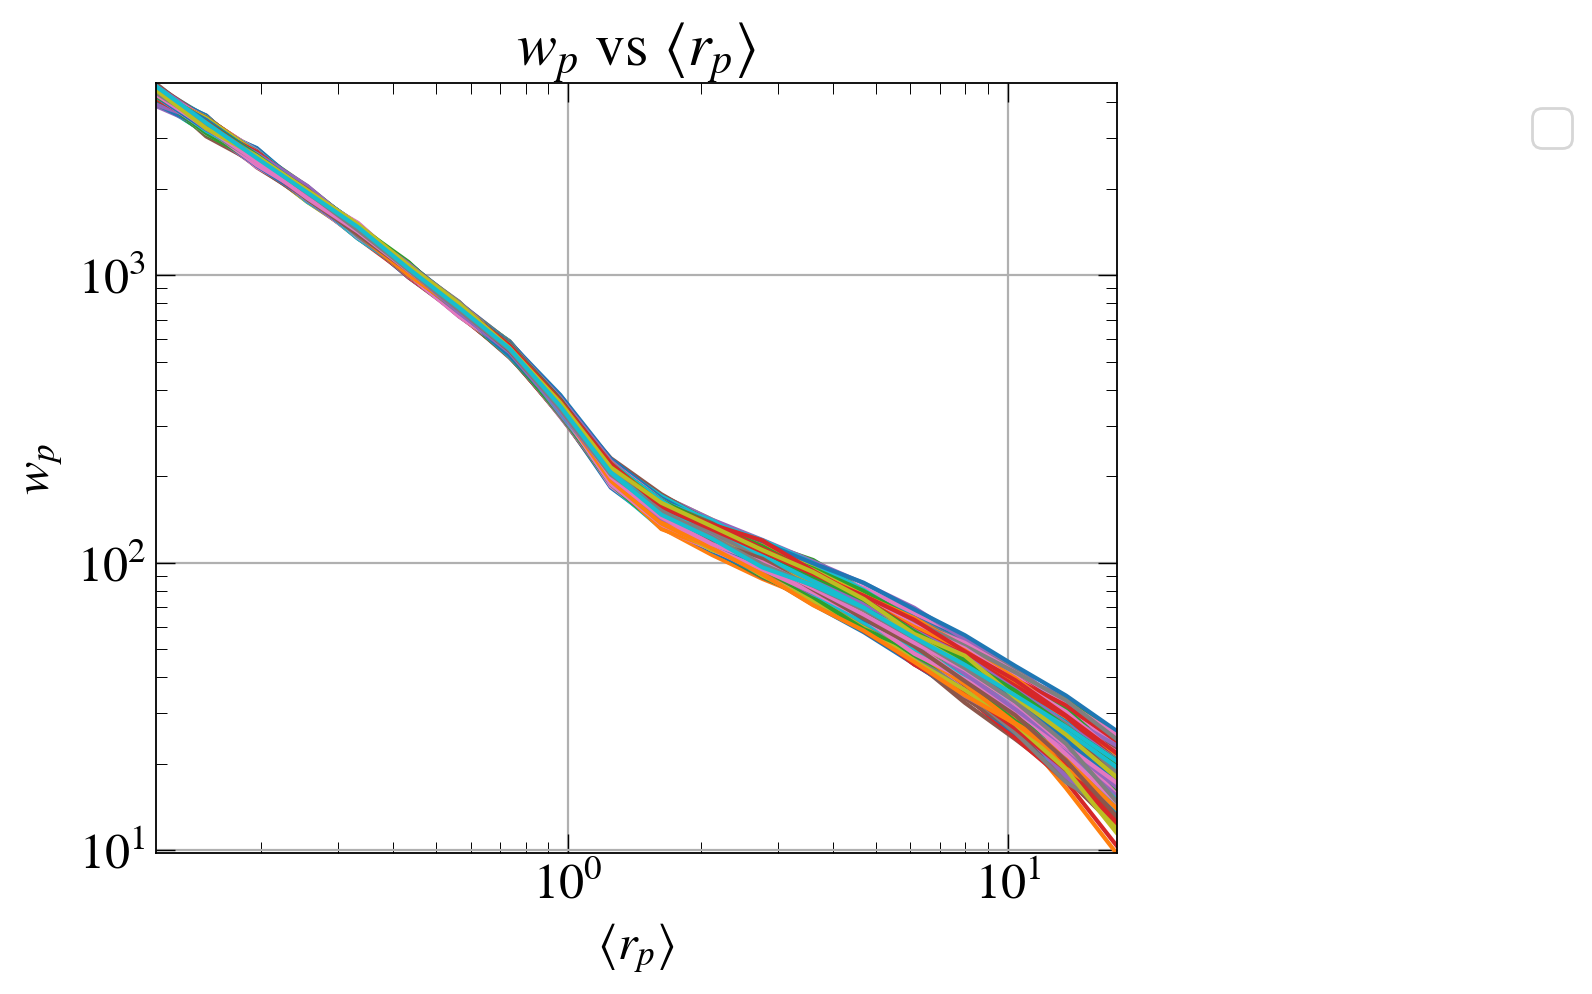

In [4]:
pg.plot_results(rp_cluster, wp_cluster)

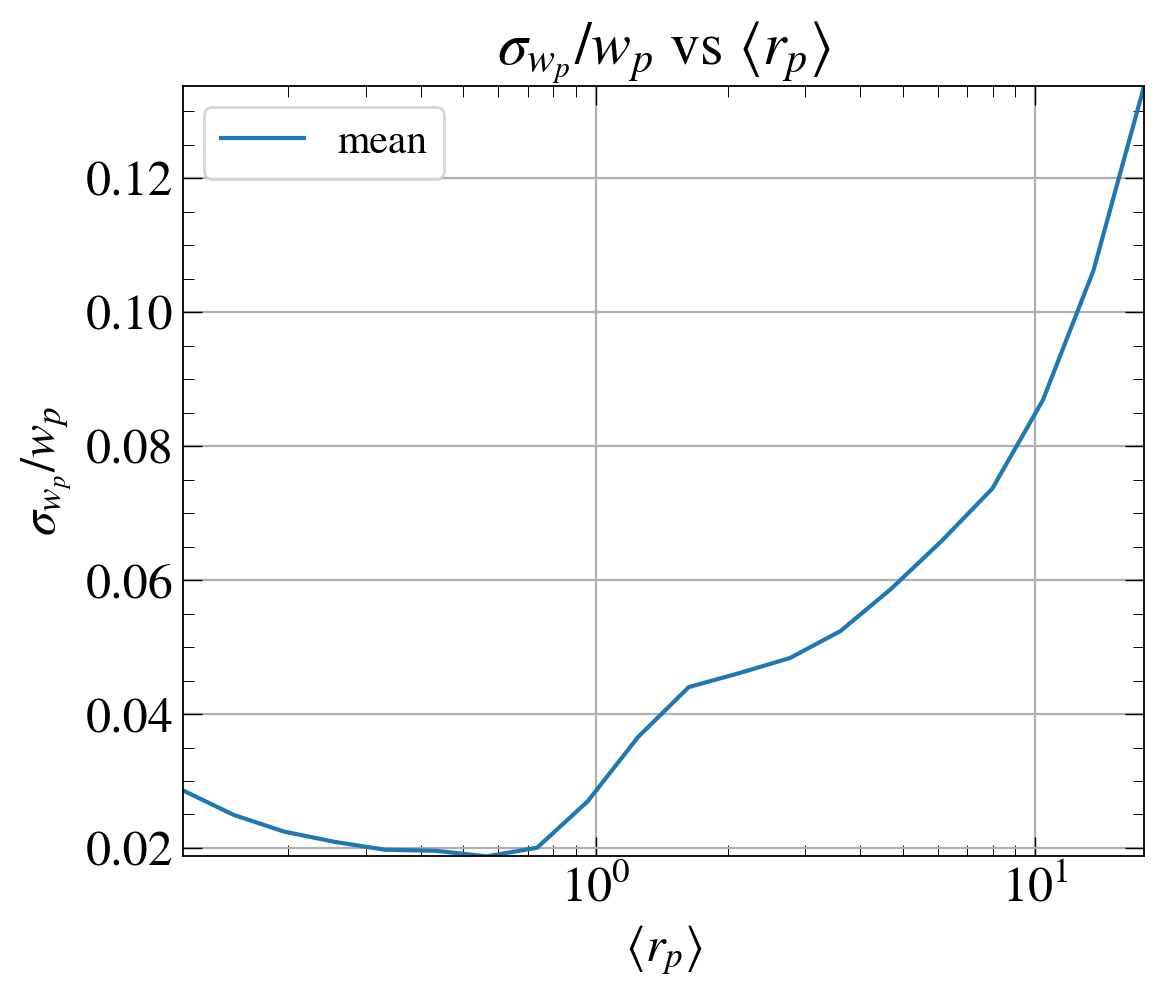

In [5]:
frac_err_c = pg.get_frac_err(stdev_c, wp_mean_c)
pg.plot_frac_err([rpavg_mean_c], [frac_err_c],labels = ['mean'])

In [6]:
wp_halos = []
rp_halos = []
for i in range (25):
    halos = np.load(f'{data_dir}wp_counts_ph{i:03d}.npz')
    wp_halos.append(halos['wp_'])
    rp_halos.append(halos['rp_avg'])
wp_halos = np.concatenate(wp_halos)
rp_halos = np.concatenate(rp_halos)

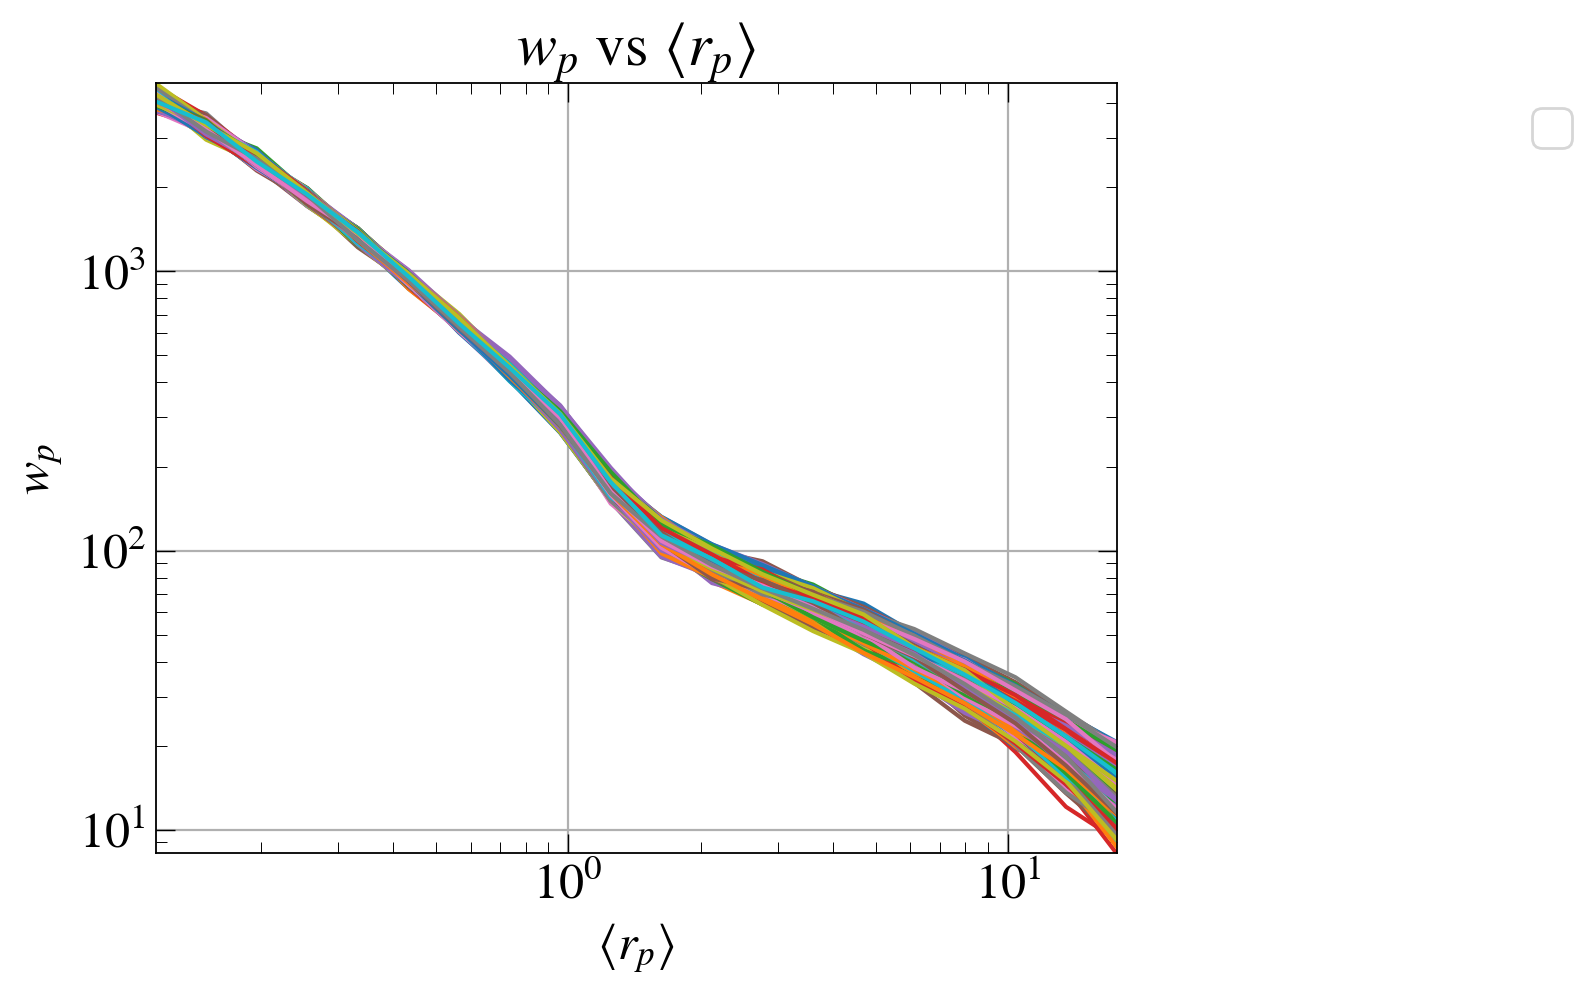

In [7]:
pg.plot_results(rp_halos, wp_halos)

17.904777715231194 4242.5594706283155
14.128022053663898 4207.923326554504


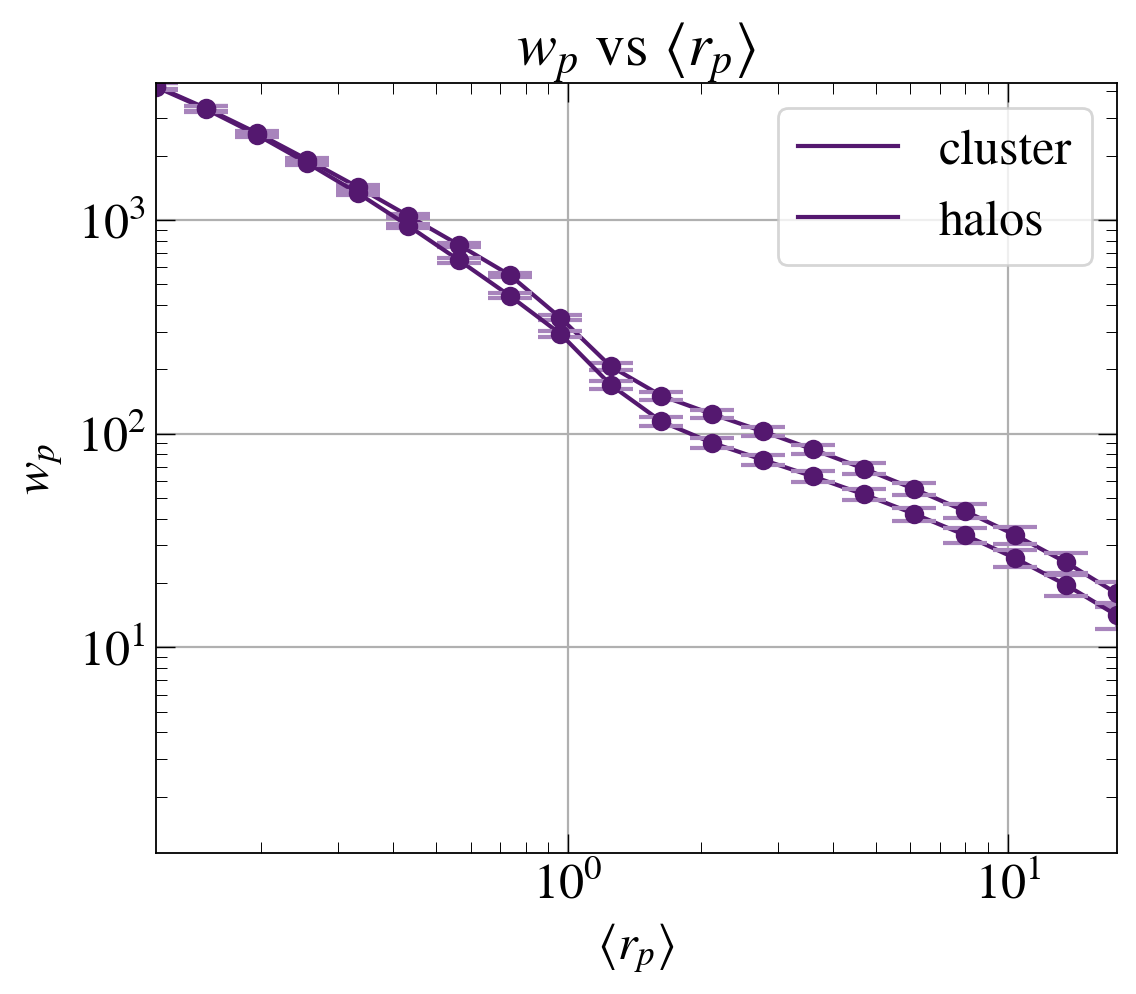

In [10]:
rpavg_mean_h, wp_mean_h, stdev_h = ct.error_data(rp_halos, wp_halos)
pg.wp_vs_rpavg(rpavg_mean_c, wp_mean_c, stdev_c, legend = 'cluster')
pg.wp_vs_rpavg(rpavg_mean_h, wp_mean_h, stdev_h, legend = 'halos')
plt.legend()
plt.show()

/tmp/ipykernel_3823627/2838567183.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


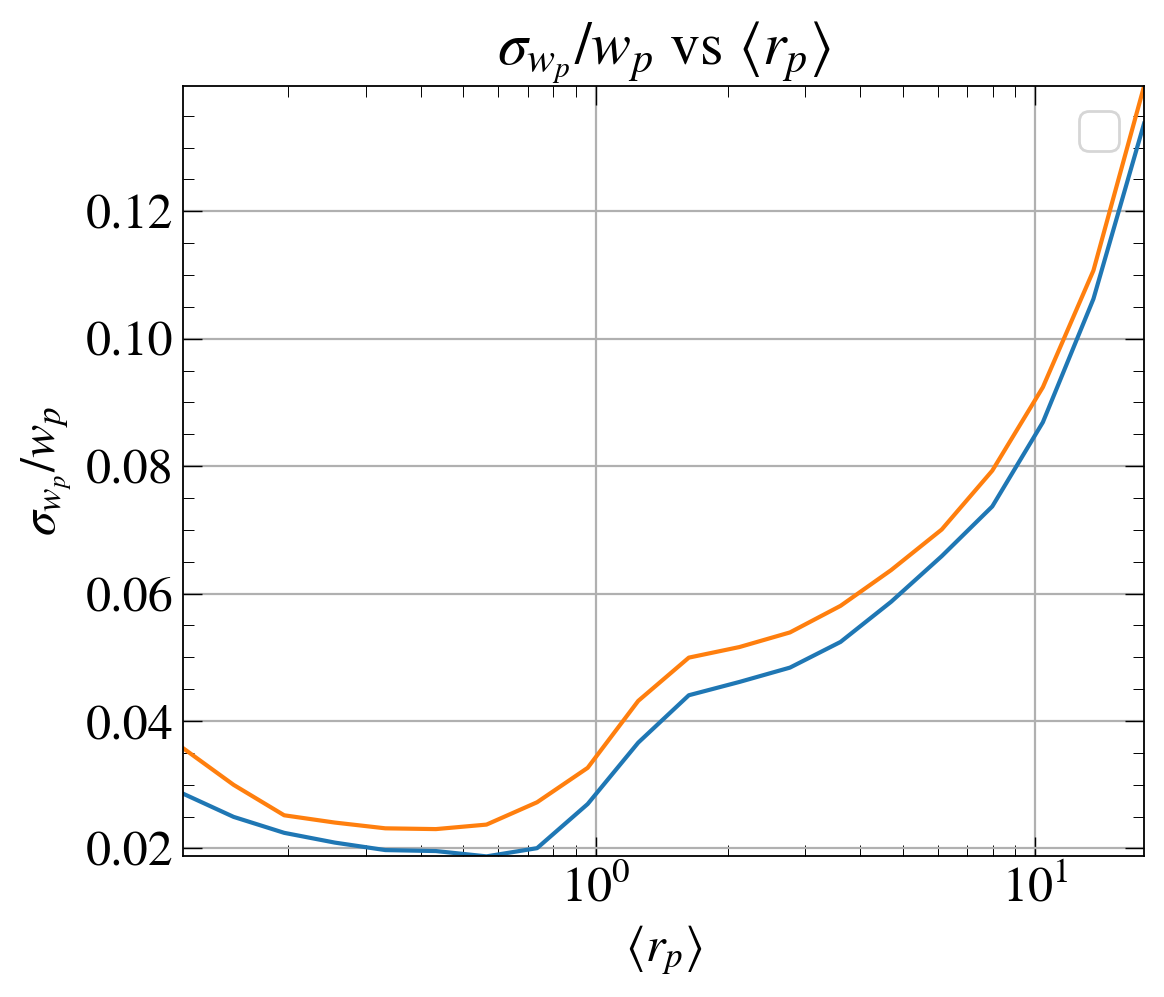

In [12]:
frac_err_h = pg.get_frac_err(stdev_h, wp_mean_h)
pg.plot_frac_err([rpavg_mean_c, rpavg_mean_h], [frac_err_c, frac_err_h],labels = ['cluster', 'halo'])
plt.legend()
plt.show()

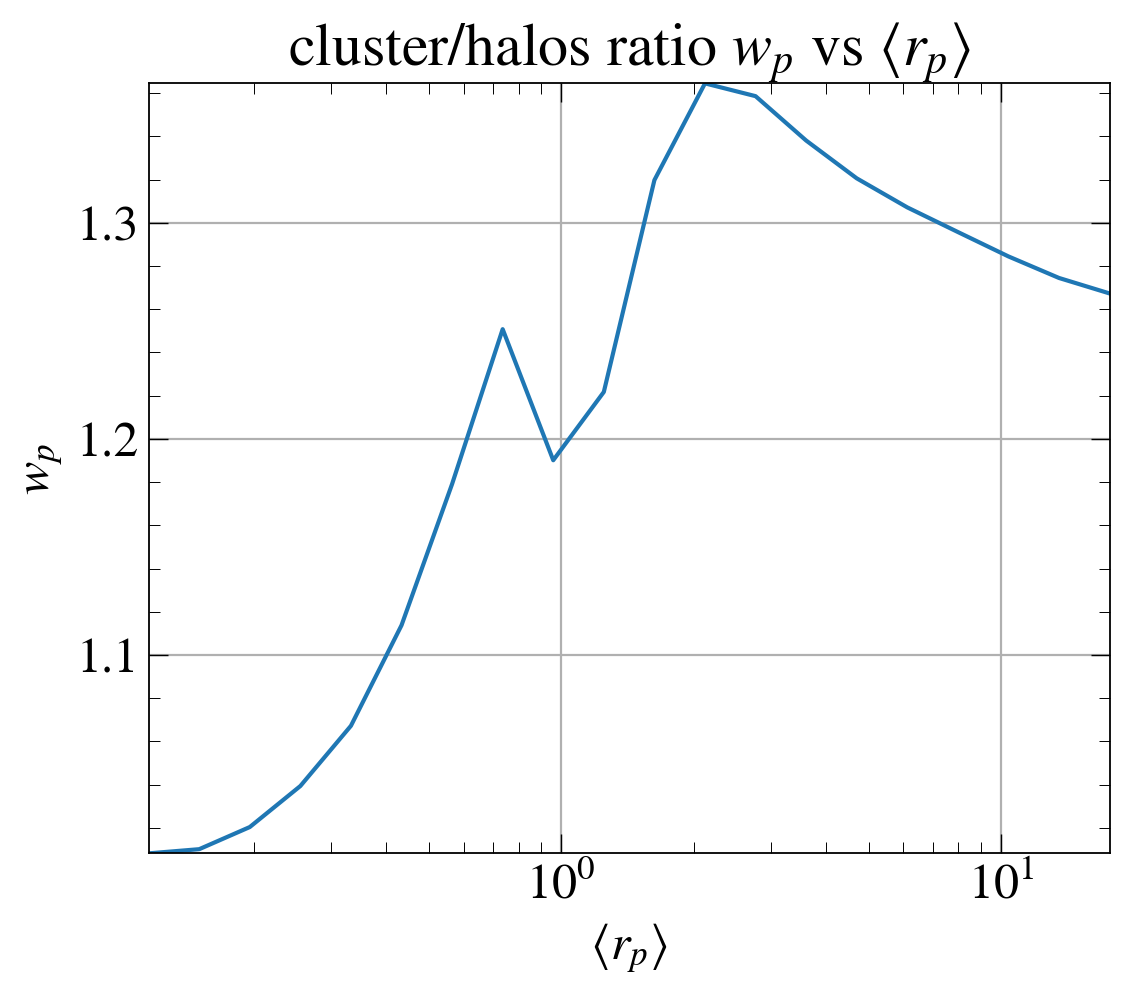

In [13]:
rpavg_mean_halos, wp_mean_halos, stdev_halos = ct.error_data(rp_halos, wp_halos)
rpavg_mean_cluster, wp_mean_cluster, stdev_clusters = ct.error_data(rp_cluster, wp_cluster)
rp = (np.array(rpavg_mean_halos) + np.array(rpavg_mean_cluster))/2
plt.plot(rp, np.array(wp_mean_cluster)/np.array(wp_mean_halos))
plt.title(r'cluster/halos ratio $w_p$ vs $\langle r_p\rangle$')
plt.xlabel(r'$\langle r_p\rangle$')
plt.ylabel(r'$w_p$')
plt.xscale('log')

# Histograms

In [ ]:
def subvolume_manual(fname, sub_ = 4, clusters = True):
    if (clusters == False):
        px, py, pz, hmass_current = su.create_data_counts(fname = fname, count_var = 'mass')
        boxsize = np.max(px)
        all_hmass = []
        sections = [boxsize*i/sub_ for i in range (1, sub_ + 1)]
        sections = np.concatenate([[0], sections])
        for x in range(len(sections) - 1):
            for y in range(len(sections) - 1):
                for z in range(len(sections) - 1):
                    filter = (px >= sections[x]) & (px < sections[x+1]) & (py >= sections[y]) & (py < sections[y+1]) & (pz >= sections[z]) & (pz < sections[z+1])
                    hmass = hmass_current[filter]
                    index = np.argsort(hmass)[-1831:]
                    hmass = hmass[index]
                    all_hmass.append(hmass)
        all_hmass = np.concatenate(all_hmass)
        return all_hmass, None
    else:
        __, __, __, cmass_current = su.create_data_counts(fname = fname, count_var = 'mass_host')
        px, py, pz, clambda_current = su.create_data_counts(fname = fname, count_var = 'lambda')
        boxsize = np.max(px)
        print(boxsize)
        all_masses = []
        all_lambdas = []
        sections = [boxsize*i/sub_ for i in range (1, sub_ + 1)]
        sections = np.concatenate([[0], sections])
        for x in range(len(sections) - 1):
            for y in range(len(sections) - 1):
                for z in range(len(sections) - 1):
                    filter = (px >= sections[x]) & (px < sections[x+1]) & (py >= sections[y]) & (py < sections[y+1]) & (pz >= sections[z]) & (pz < sections[z+1])
                    cmass = cmass_current[filter]
                    clambda = clambda_current[filter]
                    index = np.argsort(clambda)[-1831:]
                    cmass = cmass[index]
                    clambda = clambda[index]
                    all_masses.append(cmass)
                    all_lambdas.append(clambda)
        all_masses = np.concatenate(all_masses)
        all_lambdas = np.concatenate(all_lambdas)
        return all_masses, all_lambdas



## Histograms using subvolume_calc from wp_functions

In [ ]:
halos = f"{h_base}base_c000_ph001/z0p300/halos_3e+12.fit"
data = fitsio.read(halos)
mass = data['mass']

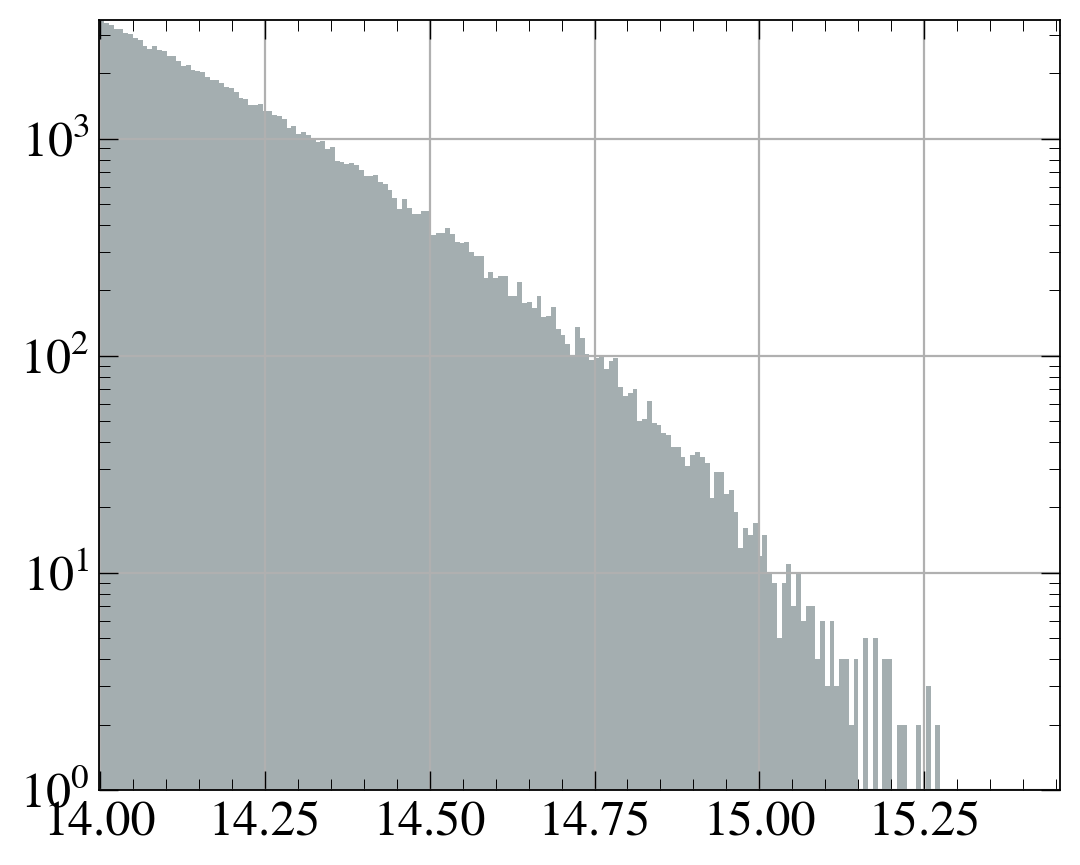

In [9]:
#plt.hist(np.log10(mass[mass > 1e14]), bins = 100)
#mass = mass[::64]
n_cut = 1831 * 64
plt.hist(np.log10(np.sort(mass))[::-1][:n_cut], bins = 200, alpha=0.5)

mass_part = np.partition(mass, -n_cut)[-n_cut:]
plt.hist(np.log10(mass_part), bins = 200, alpha=0.2)
plt.yscale('log')


In [ ]:
cmass = []
clambda = []
hmass = []
for i in range(25):

    clusters = f"{c_base}base_c000_ph{i:03d}/z0p300/model_hod000000/richness_q180_bg.fit"
    halos = f"/{c_base}base_c000_ph{i:03d}/z0p300/halos_3e+12.fit"

    __, __, __, cmass_current = su.create_data_counts(fname = clusters, count_var = 'mass_host')
    __, __, __, clambda_current = su.create_data_counts(fname = clusters, count_var = 'lambda')
    cx, cy, cz, cidx, csections, cbins = su.subvolume_calc(fname = clusters, sub_ = sub_, var = 'lambda', counts = 1831, hist=True)
    cmass_current = cmass_current[cidx]
    clambda_current = clambda_current[cidx]
    cmass.append(cmass_current)
    clambda.append(clambda_current)

    __, __, __, hmass_current = su.create_data_counts(fname = halos, count_var = 'mass')
    hx, hy, hz, hidx, hsections, hbins = su.subvolume_calc(fname = halos, sub_ = sub_, var = 'mass', counts = 1831, hist=True)
    hmass_current = hmass_current[hidx]
    hmass.append(hmass_current)

cmass = np.concatenate(cmass)
clambda = np.concatenate(clambda)
hmass = np.concatenate(hmass)

0.0325598 246.016
20.1787 246.016
0.0316773 134.931
20.2761 134.931
0.06228 141.786
19.8722 141.786
0.0242076 173.184
20.3736 173.184
0.0434517 237.686
20.6216 237.686
0.0194047 197.545
20.425 197.545
0.0134827 174.528
19.9983 174.528
0.00774656 167.956
19.8423 167.956
0.0395995 141.895
20.7122 141.895
0.0286448 154.729
19.7662 154.729
0.0366429 193.636
20.5497 193.636
0.0268202 208.046
19.9632 208.046
0.0101079 182.108
20.3742 182.108
0.0105319 174.186
21.3572 174.186
0.00167048 173.232
20.7425 173.232
0.013489 138.183
19.8111 138.183
0.01078 173.92
20.3666 173.92
0.0317497 132.549
21.0371 132.549
0.00748864 180.264
20.0311 180.264
0.0418096 160.497
19.8696 160.497
0.0169836 158.739
20.1876 158.739
0.0149191 190.916
20.1686 190.916
0.0720295 160.291
19.9556 160.291
0.00123238 136.236
20.3331 136.236
0.0148542 125.817
19.9984 125.817
0.00828084 130.714
19.873 130.714
0.0287993 154.253
20.8123 154.253
0.032122 129.666
19.5431 129.666
0.00614761 281.5
21.113 281.5
0.0041398 155.613
20.15

3.328131e+12 , 4.382939e+15


Text(0, 0.5, 'counts')

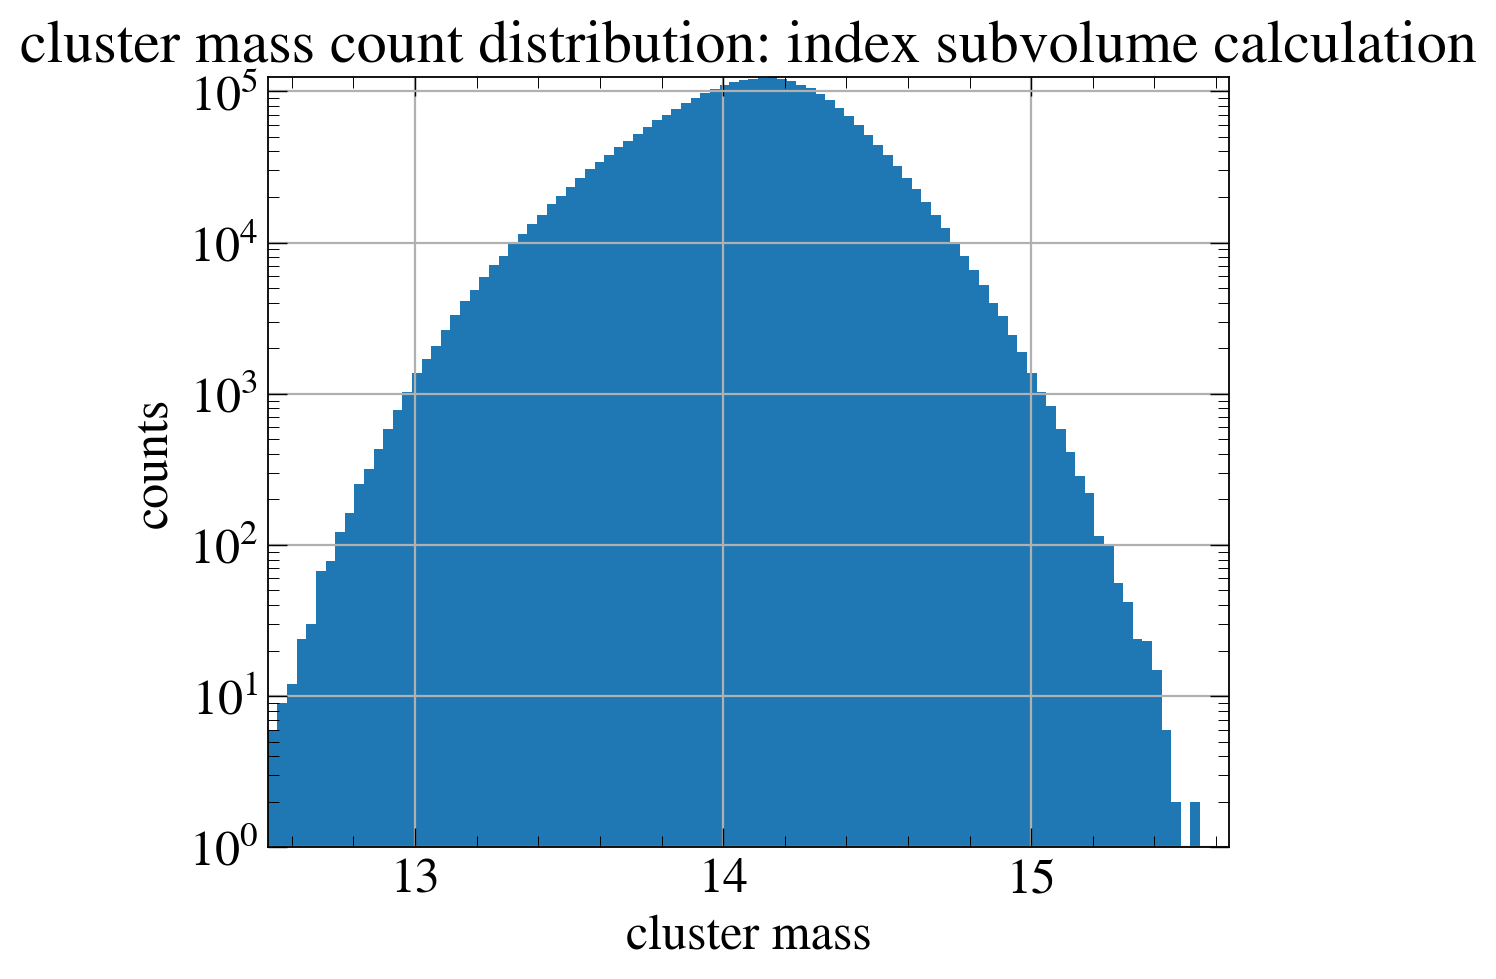

In [12]:
print(f"{np.min(cmass):e} , {np.max(cmass):e}")
#3163622000000.0 2440106000000000.0
plt.hist(np.log10(cmass), bins = 100)
plt.yscale('log')
plt.title(r'cluster mass count distribution: index subvolume calculation')
plt.xlabel(r'cluster mass')
plt.ylabel(r'counts')

18.9671 425.631


Text(0, 0.5, 'counts')

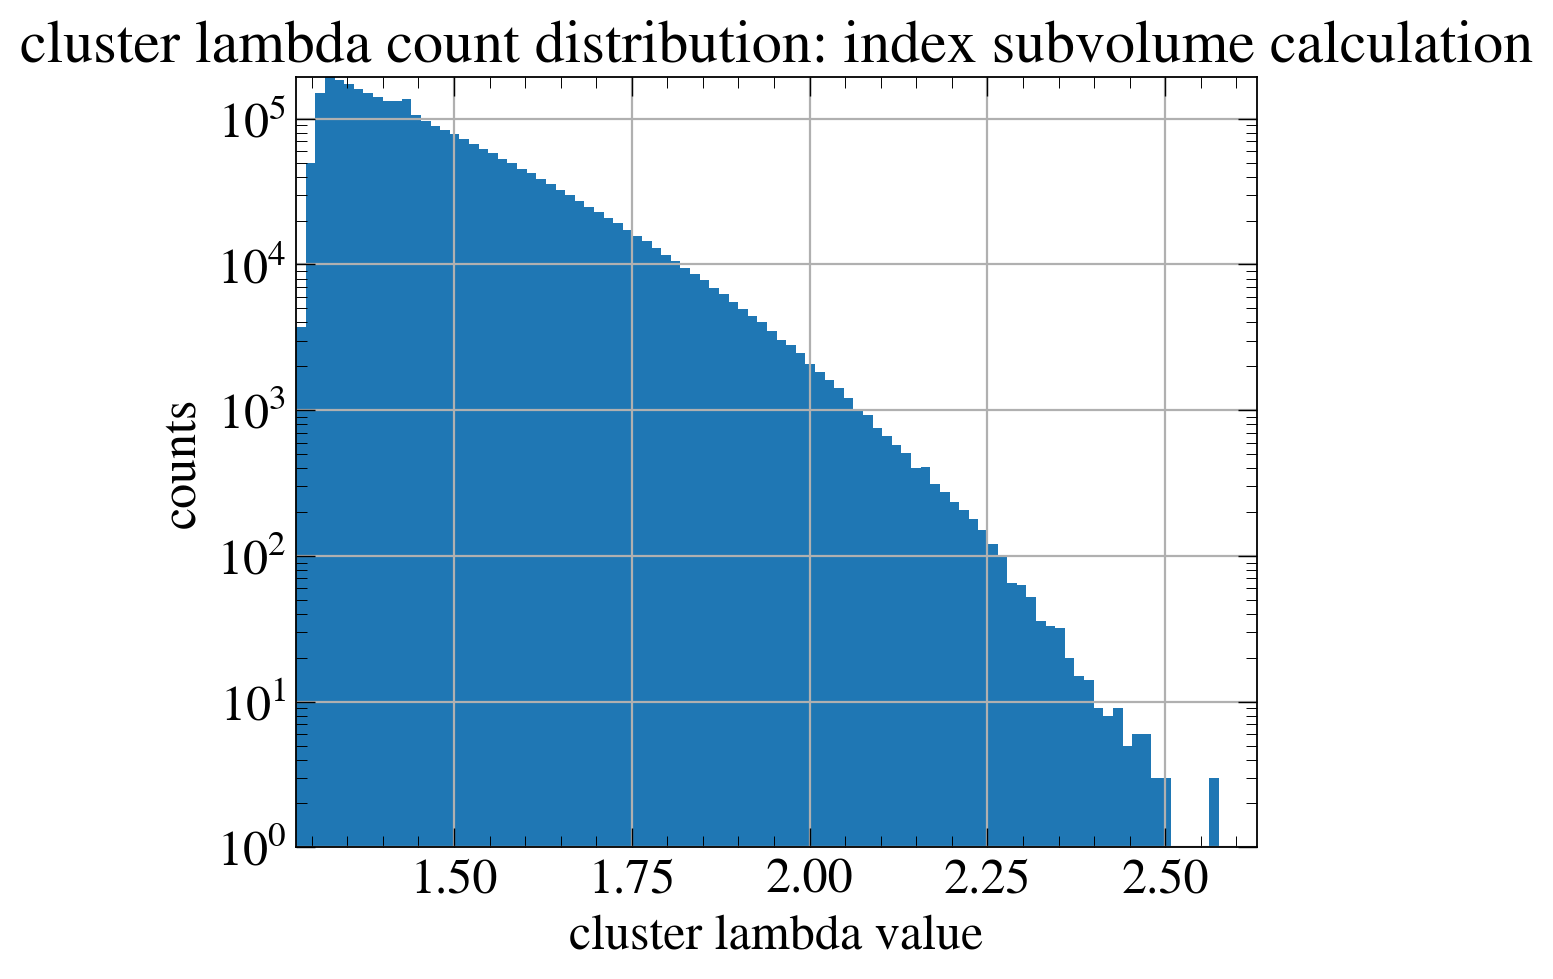

In [13]:
print(np.min(clambda) , np.max(clambda))
plt.hist(np.log10(clambda), bins = 100)
plt.yscale('log')
plt.title(r'cluster lambda count distribution: index subvolume calculation')
plt.xlabel(r'cluster lambda value')
plt.ylabel(r'counts')

9.304846e+13, f4.382939e+15


Text(0, 0.5, 'counts')

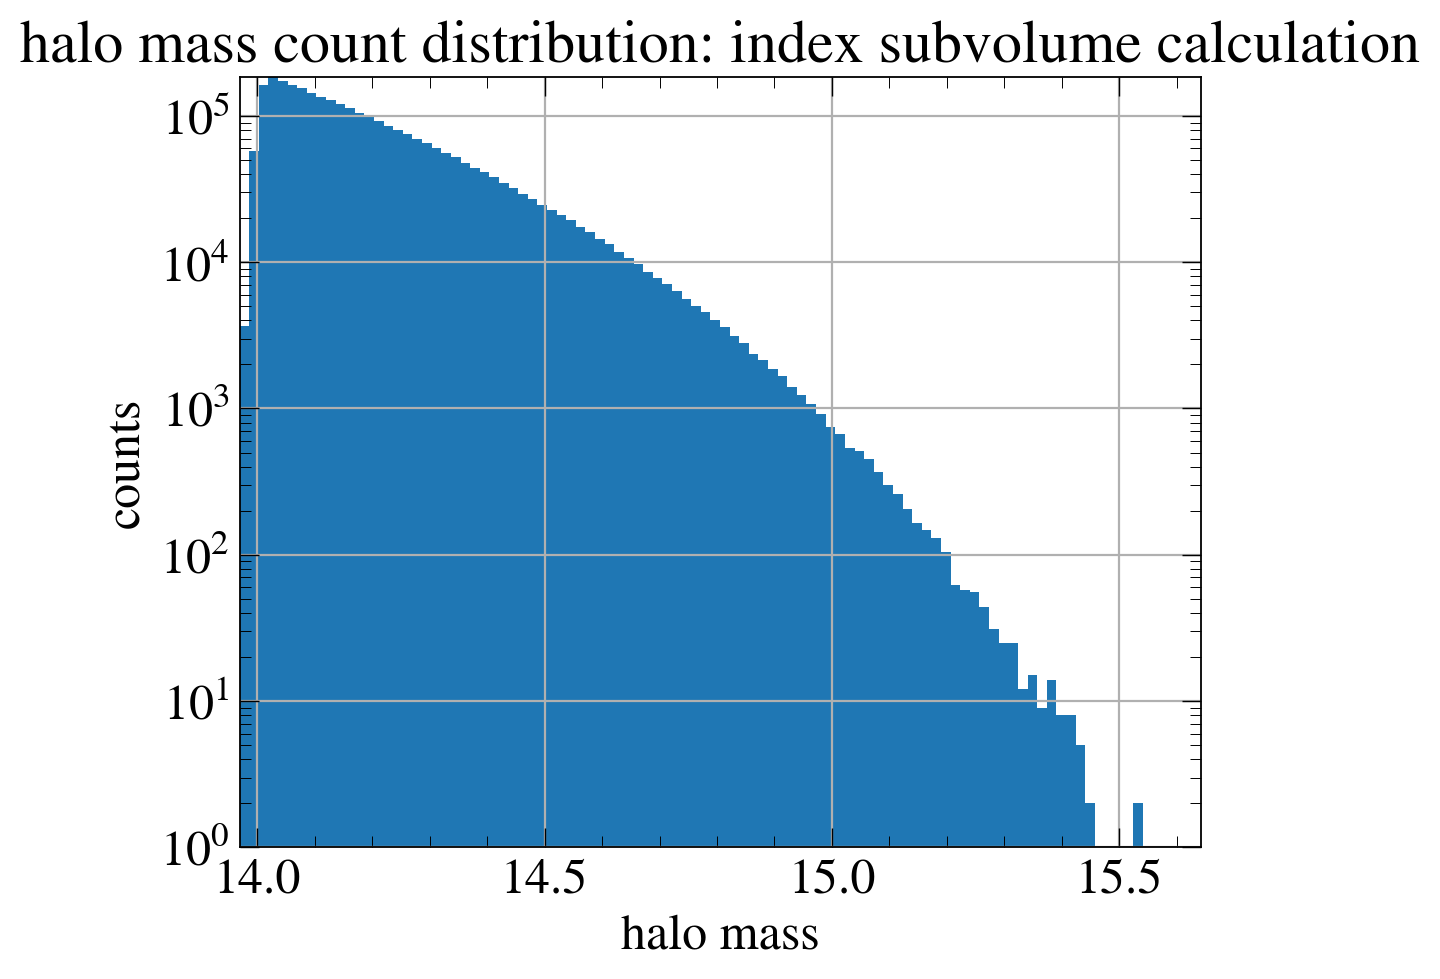

In [14]:
print(f'{np.min(hmass):e}, f{np.max(hmass):e}')
plt.hist(np.log10(hmass), bins = 100)
plt.yscale('log')
plt.title(r'halo mass count distribution: index subvolume calculation')
plt.xlabel(r'halo mass')
plt.ylabel(r'counts')

## Histograms using subvolume_manual

In [ ]:
hmasses = []
for i in range(25):
    halos = f"{h_base}base_c000_ph{i:03d}/z0p300/halos_3e+12.fit"
    halos_current, ___ = subvolume_manual(fname = halos, sub_ = sub_, clusters = False)
    hmasses.append(halos_current)
hmasses = np.concatenate(hmasses)

Text(0.5, 1.0, 'halo mass count distribution')

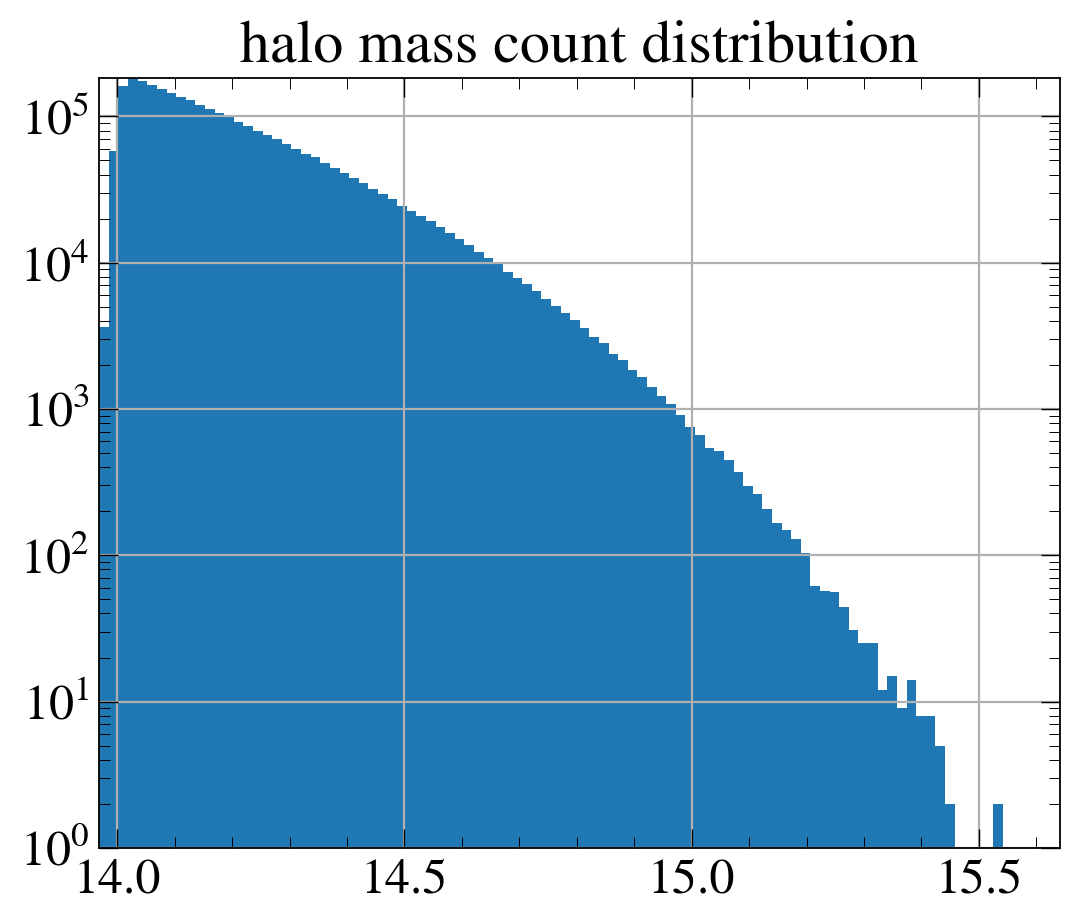

In [19]:
plt.hist(np.log10(hmasses), bins = 100)
plt.yscale('log')
plt.title(r'halo mass count distribution')

In [ ]:
cmasses = []
clambdas = []
for i in range(25):
    clusters = f"{c_base}base_c000_ph{i:03d}/z0p300/model_hod000000/richness_q180_bg.fit"
    mass_current, lanbda_current = subvolume_manual(fname = clusters, sub_ = sub_)
    cmasses.append(mass_current)
    clambdas.append(lanbda_current)
cmasses = np.concatenate(cmasses)
clambdas = np.concatenate(clambdas)

2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0
2000.0


Text(0.5, 1.0, 'cluster mass count distribution')

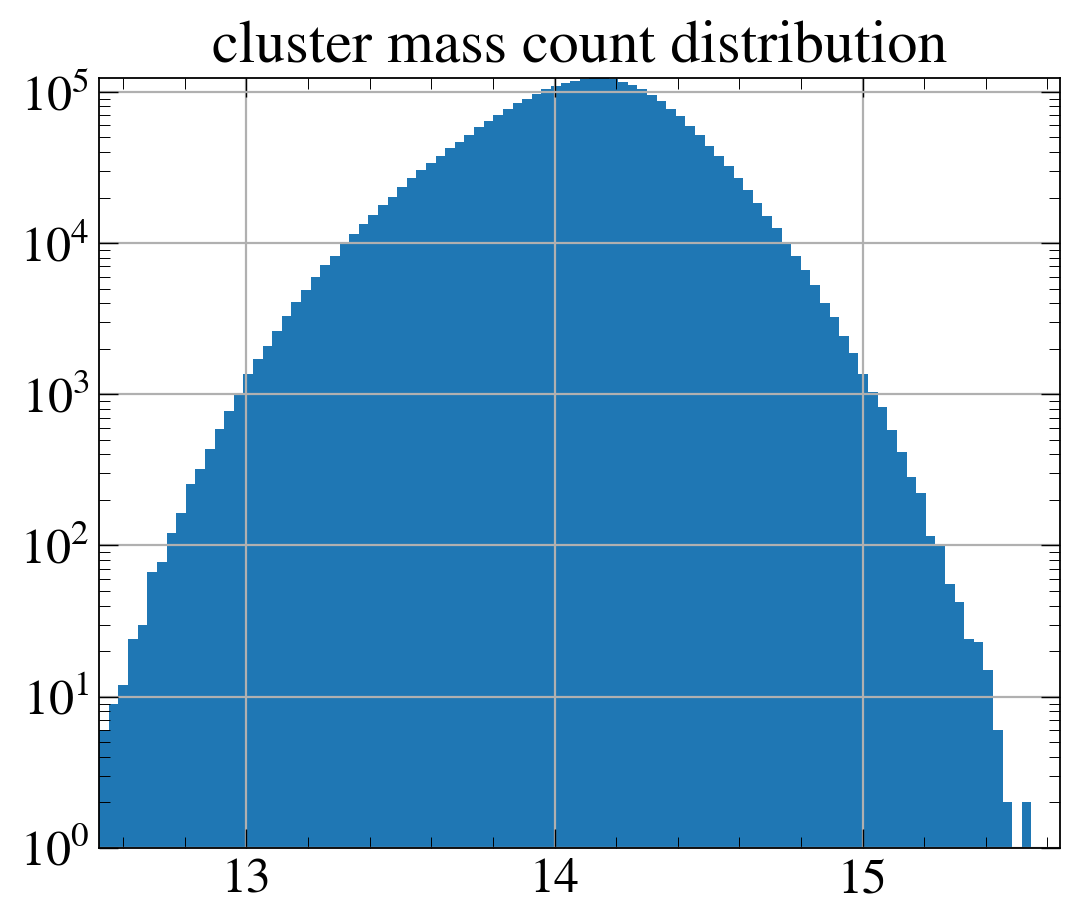

In [11]:
plt.hist(np.log10(cmasses), bins = 100)
plt.yscale('log')
plt.title(r'cluster mass count distribution')

Text(0.5, 1.0, 'cluster lambda count distribution')

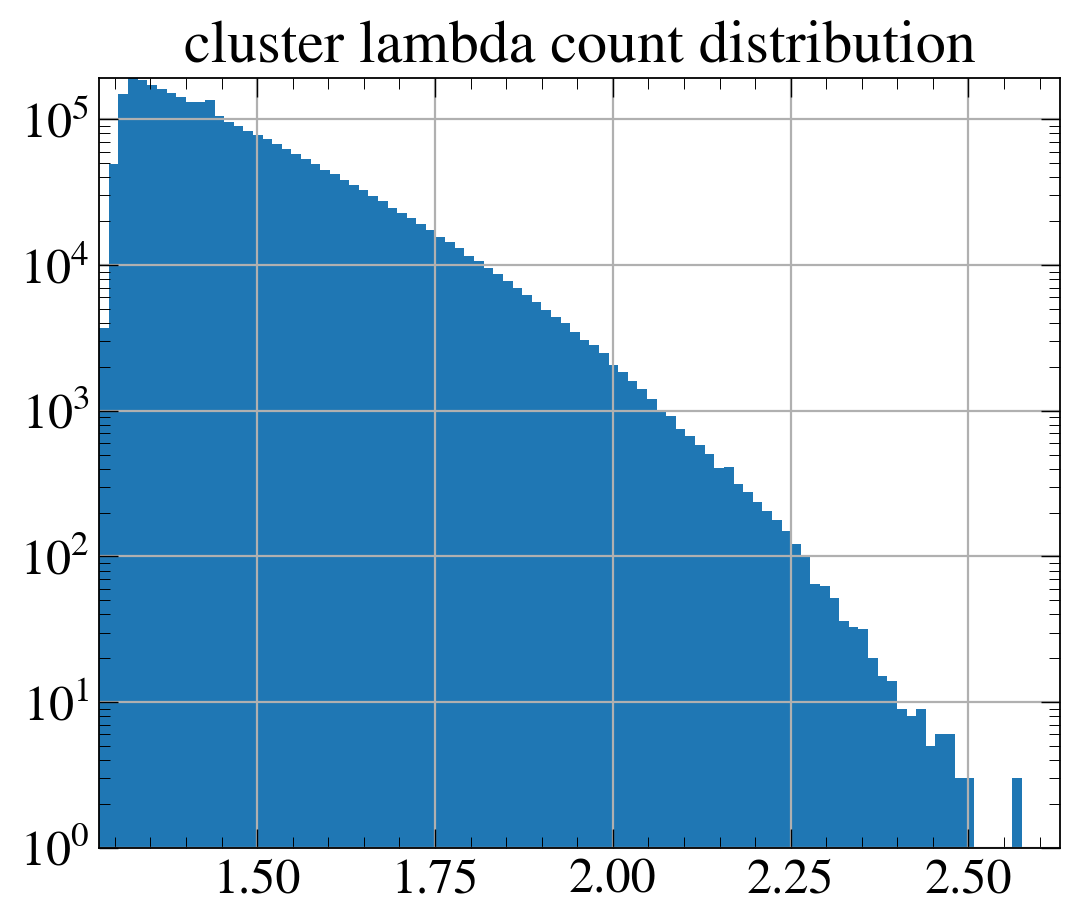

In [12]:
plt.hist(np.log10(clambdas), bins = 100)
plt.yscale('log')
plt.title(r'cluster lambda count distribution')

# Calculations for 1 box

2000.0


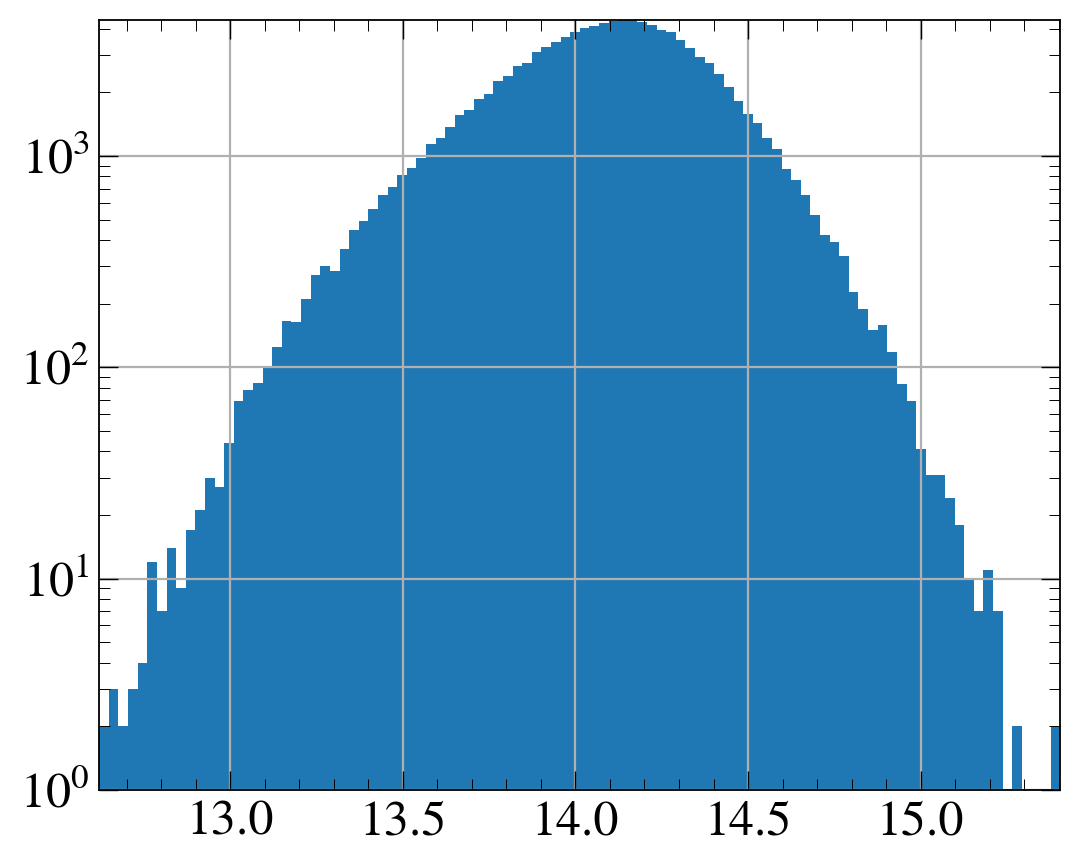

In [6]:
all_masses, all_lambdas = subvolume_manual(clusters)
plt.hist(np.log10(all_masses), bins = 100)
plt.yscale('log')

3163622000000.0 2537691000000000.0


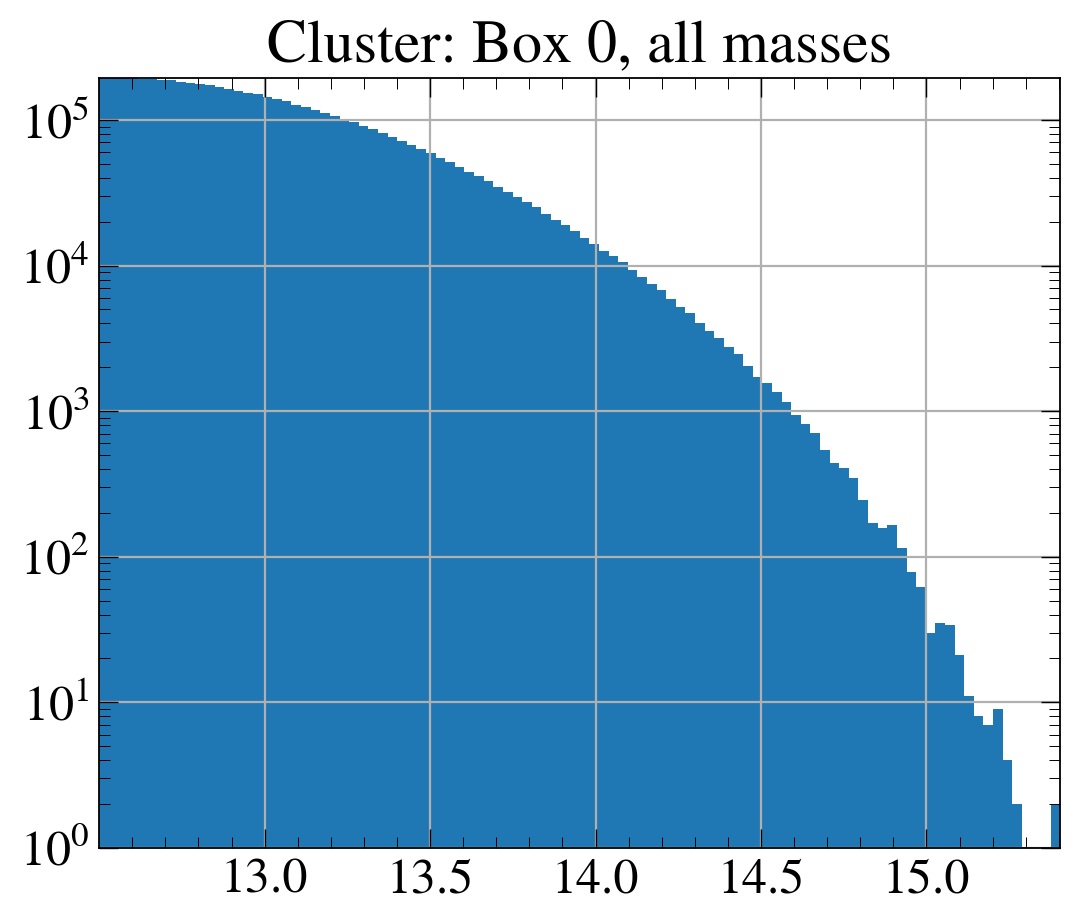

In [ ]:
clusters = f"{c_base}base_c000_ph000/z0p300/model_hod000000/richness_q180_bg.fit"
__, __, __, cmass_current = su.create_data_counts(fname = clusters, count_var = 'mass_host')
__, __, __, clambda_current = su.create_data_counts(fname = clusters, count_var = 'lambda')
length_ = len(cmass_current)
plt.hist(np.log10(cmass_current), bins=100)#, bins = 'fd')
plt.semilogy()
title = "Cluster counts: Box 0, all masses, mass counts: ", str(length_)
plt.title("Cluster: Box 0, all masses")
print(np.min(cmass_current), np.max(cmass_current))


0.0325598 246.016
20.1787 246.016
0.0316773 134.931
20.2761 134.931
0.06228 141.786
19.8722 141.786
0.0242076 173.184
20.3736 173.184
0.0434517 237.686
20.6216 237.686
0.0194047 197.545
20.425 197.545
0.0134827 174.528
19.9983 174.528
0.00774656 167.956
19.8423 167.956
0.0395995 141.895
20.7122 141.895
0.0286448 154.729
19.7662 154.729
0.0366429 193.636
20.5497 193.636
0.0268202 208.046
19.9632 208.046
0.0101079 182.108
20.3742 182.108
0.0105319 174.186
21.3572 174.186
0.00167048 173.232
20.7425 173.232
0.013489 138.183
19.8111 138.183
0.01078 173.92
20.3666 173.92
0.0317497 132.549
21.0371 132.549
0.00748864 180.264
20.0311 180.264
0.0418096 160.497
19.8696 160.497
0.0169836 158.739
20.1876 158.739
0.0149191 190.916
20.1686 190.916
0.0720295 160.291
19.9556 160.291
0.00123238 136.236
20.3331 136.236
0.0148542 125.817
19.9984 125.817
0.00828084 130.714
19.873 130.714
0.0287993 154.253
20.8123 154.253
0.032122 129.666
19.5431 129.666
0.00614761 281.5
21.113 281.5
0.0041398 155.613
20.15

Text(0.5, 1.0, 'Cluster counts: Box 0, masses of top 1831 lambda')

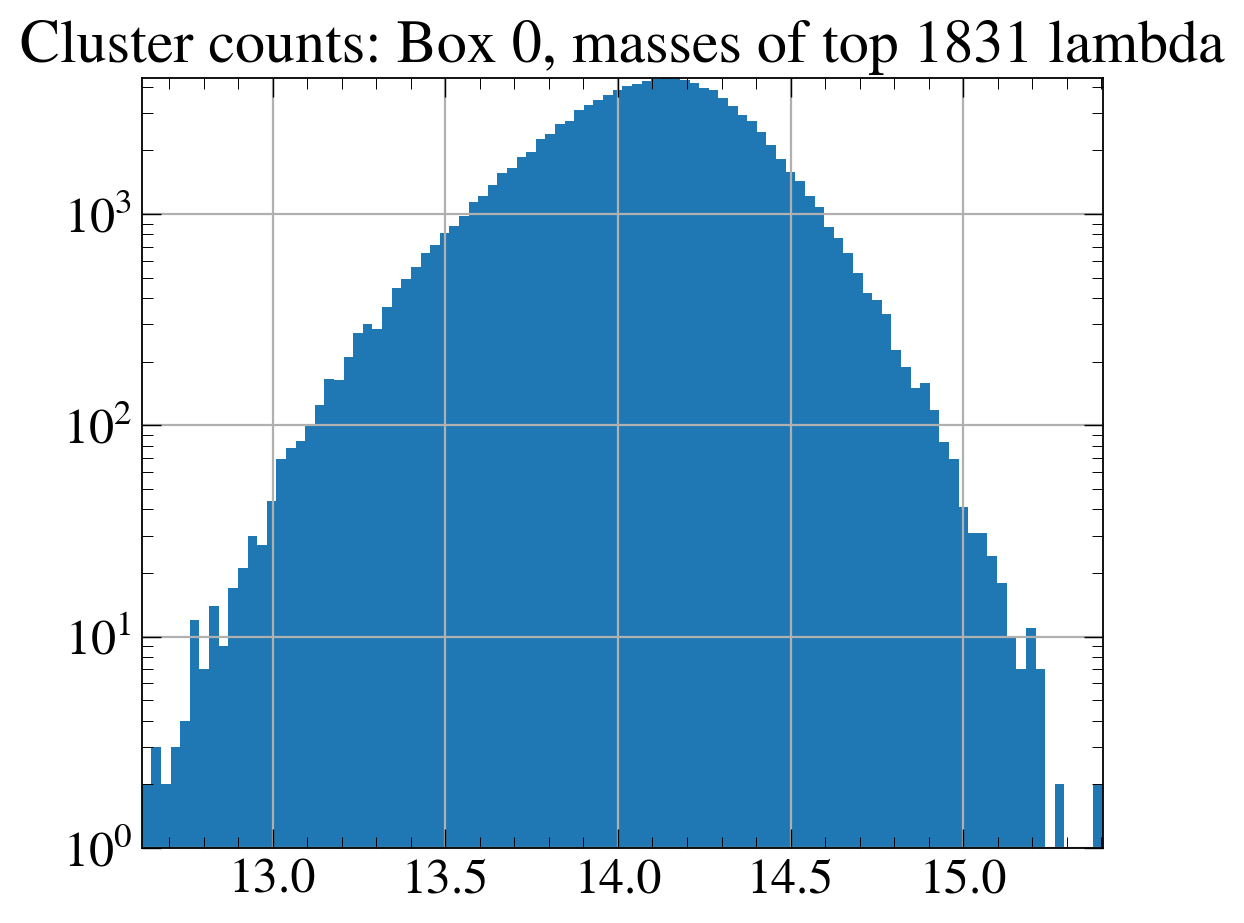

In [ ]:
clusters = f"/projects/hywu/cluster_sims/cluster_finding/data/emulator_data/base_c000_ph000/z0p300/model_hod000000/richness_q180_bg.fit"
__, __, __, cmass_current = su.create_data_counts(fname = clusters, count_var = 'mass_host')
__, __, __, clambda_current = su.create_data_counts(fname = clusters, count_var = 'lambda')
x, y, z, indexes, sections, bins_ = su.subvolume_calc(fname = clusters, sub_ = sub_, var = 'lambda', counts = 1831, hist=True)
cmass_current = cmass_current[indexes]
clambda_current = clambda_current[indexes]
length_ = len(cmass_current)
plt.hist(np.log10(cmass_current), bins = 100)
plt.semilogy()
plt.title("Cluster counts: Box 0, masses of top 1831 lambda")

19.3234 314.798


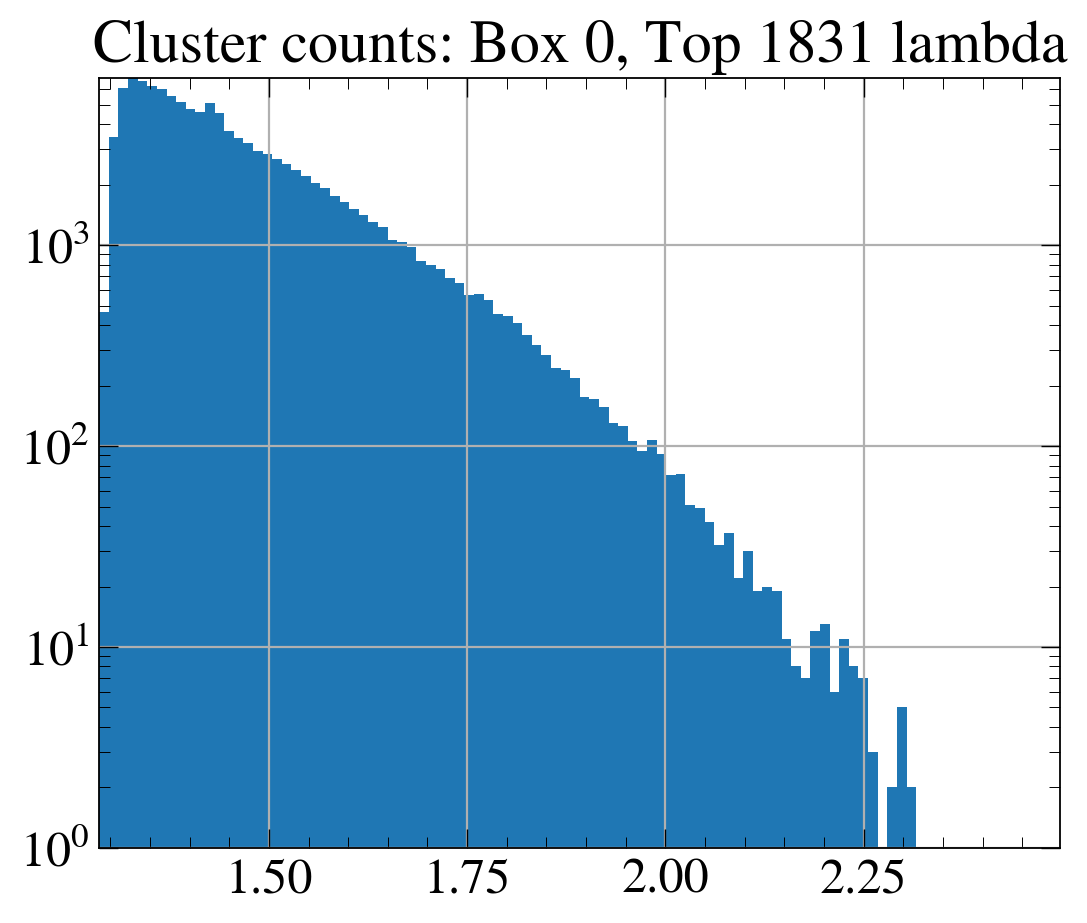

In [12]:
plt.hist(np.log10(clambda_current), bins = 100)
plt.semilogy()
plt.title("Cluster counts: Box 0, Top 1831 lambda")
print(np.min(clambda_current), np.max(clambda_current))